**Rough Bergomi**

- Compare magic-strike and Fukasawa estimates in the rough Bergomi model.

In [7]:
# Install from GitHub only when running in Google Colab.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "git+https://github.com/fbourgey/bergomi-guyon.git",
        ],
        check=True,
    )

# Imports

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from magic_strikes.rough_bergomi import RoughBergomiModel, get_params_rough_bergomi

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234
SAVEFIG = False

# Rough Bergomi

Set model parameters

In [8]:
set_id = 1
params, xi0 = get_params_rough_bergomi(id=set_id)
rbergomi = RoughBergomiModel(params, xi0)
print(rbergomi)

RoughBergomiModel with parameters:
eta=1.5, H=0.23, rho=-0.62, s0=1.0.


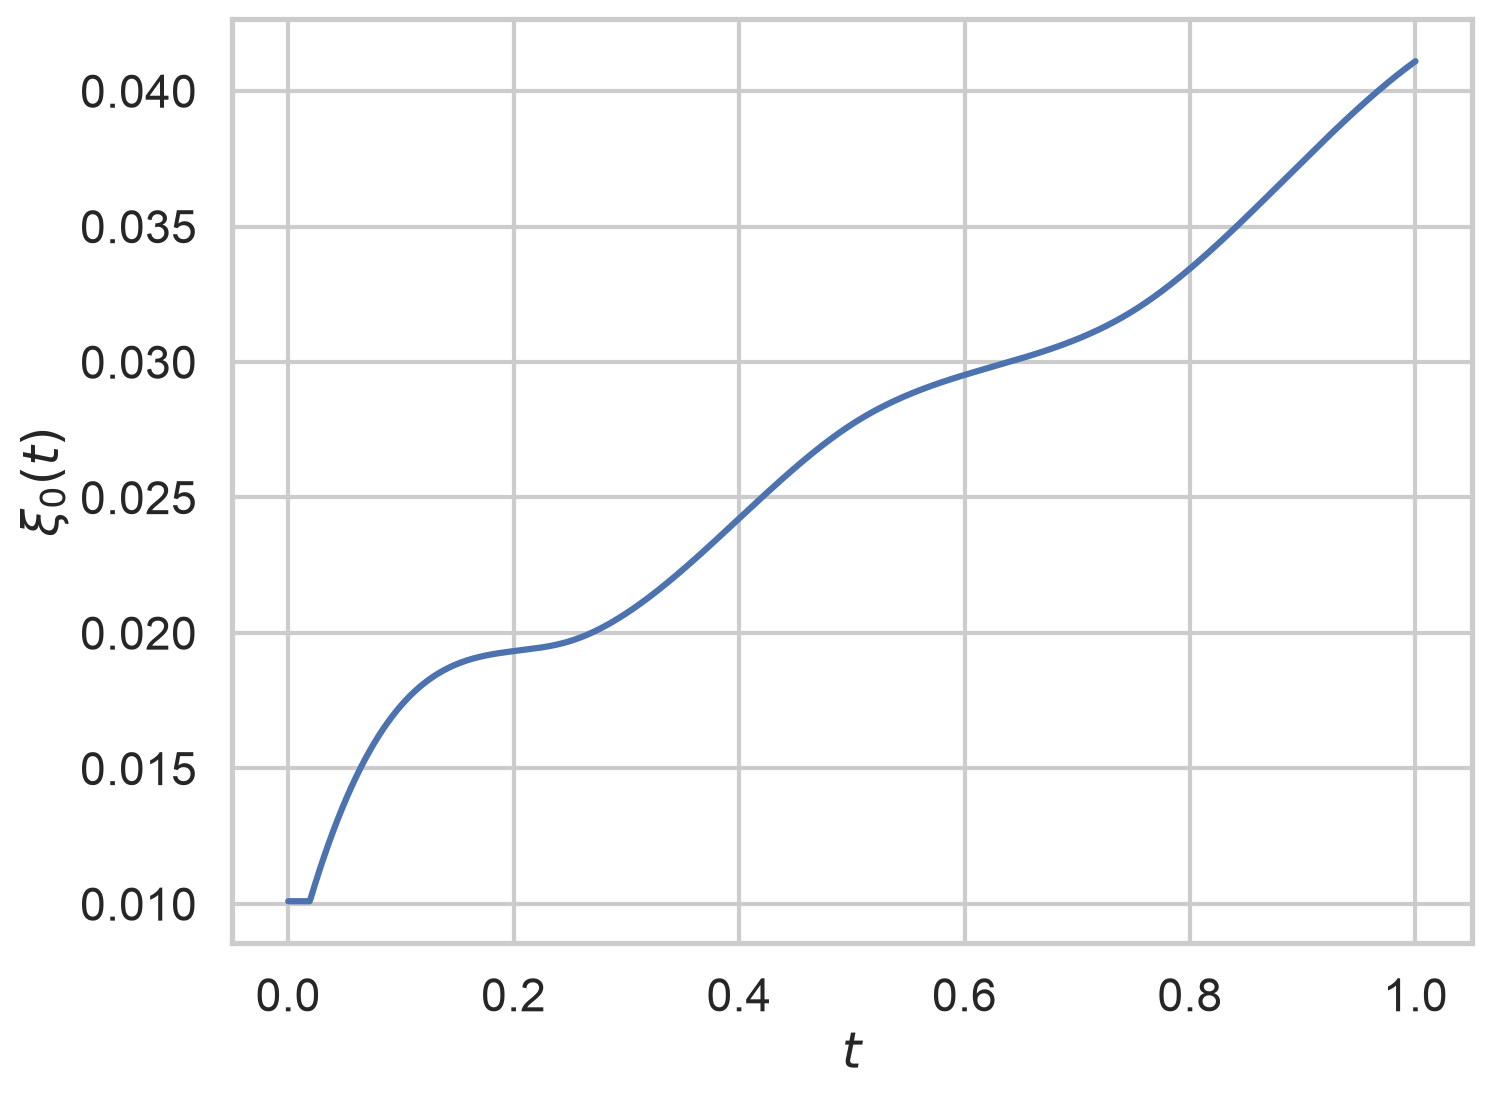

In [9]:
ts = np.linspace(0.0, 1.0, 1000)
fig, ax = plt.subplots()
ax.plot(ts, rbergomi.xi0(ts))
ax.set_xlabel("$t$")
ax.set_ylabel(r"$\xi_0(t)$")
if SAVEFIG:
    fig.savefig(f"figures/xi0_rbergomi_set_{set_id}.pdf", bbox_inches="tight")
plt.show()

In [10]:
n_mc = 3 * 10**5
n_disc = 300
n_loop = 1
n_batch = 5  # Monte Carlo error
Ts = np.linspace(0.5e-1, 1.0, 15)

In [11]:
bundled = rbergomi.swap_mc_estimators(
    T=Ts,
    n_mc=n_mc,
    n_disc=n_disc,
    n_loop=n_loop,
    seed=SEED,
    n_batch=n_batch,
    verbose=True,
    antithetic=True,
)


Computing shared Monte Carlo swap estimators:
---------------------------------------------
Model: RoughBergomiModel
Maturity T:  [0.05       0.11785714 0.18571429 0.25357143 0.32142857 0.38928571
 0.45714286 0.525      0.59285714 0.66071429 0.72857143 0.79642857
 0.86428571 0.93214286 1.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Number of simulation loops: 1
Number of independent batches: 5


Running batch 1/5 with seed 4206279609
1/15: expiry 0.0500
2/15: expiry 0.1179
3/15: expiry 0.1857
4/15: expiry 0.2536
5/15: expiry 0.3214
6/15: expiry 0.3893
7/15: expiry 0.4571
8/15: expiry 0.5250
9/15: expiry 0.5929
10/15: expiry 0.6607
11/15: expiry 0.7286
12/15: expiry 0.7964
13/15: expiry 0.8643
14/15: expiry 0.9321
15/15: expiry 1.0000
Computing magic strikes for T=0.0500... (1/15)
Computing magic strikes for T=0.1179... (2/15)
Computing magic strikes for T=0.1857... (3/15)
Computing magic strikes for T=0.2536... (4/15)
Computing magic strikes for T=0.3214... (5/15)
Com

In [12]:
out_mc = bundled["mc"]
out_magic_strikes = bundled["magic_strikes"]
out_fukasawa = bundled["fukasawa"]

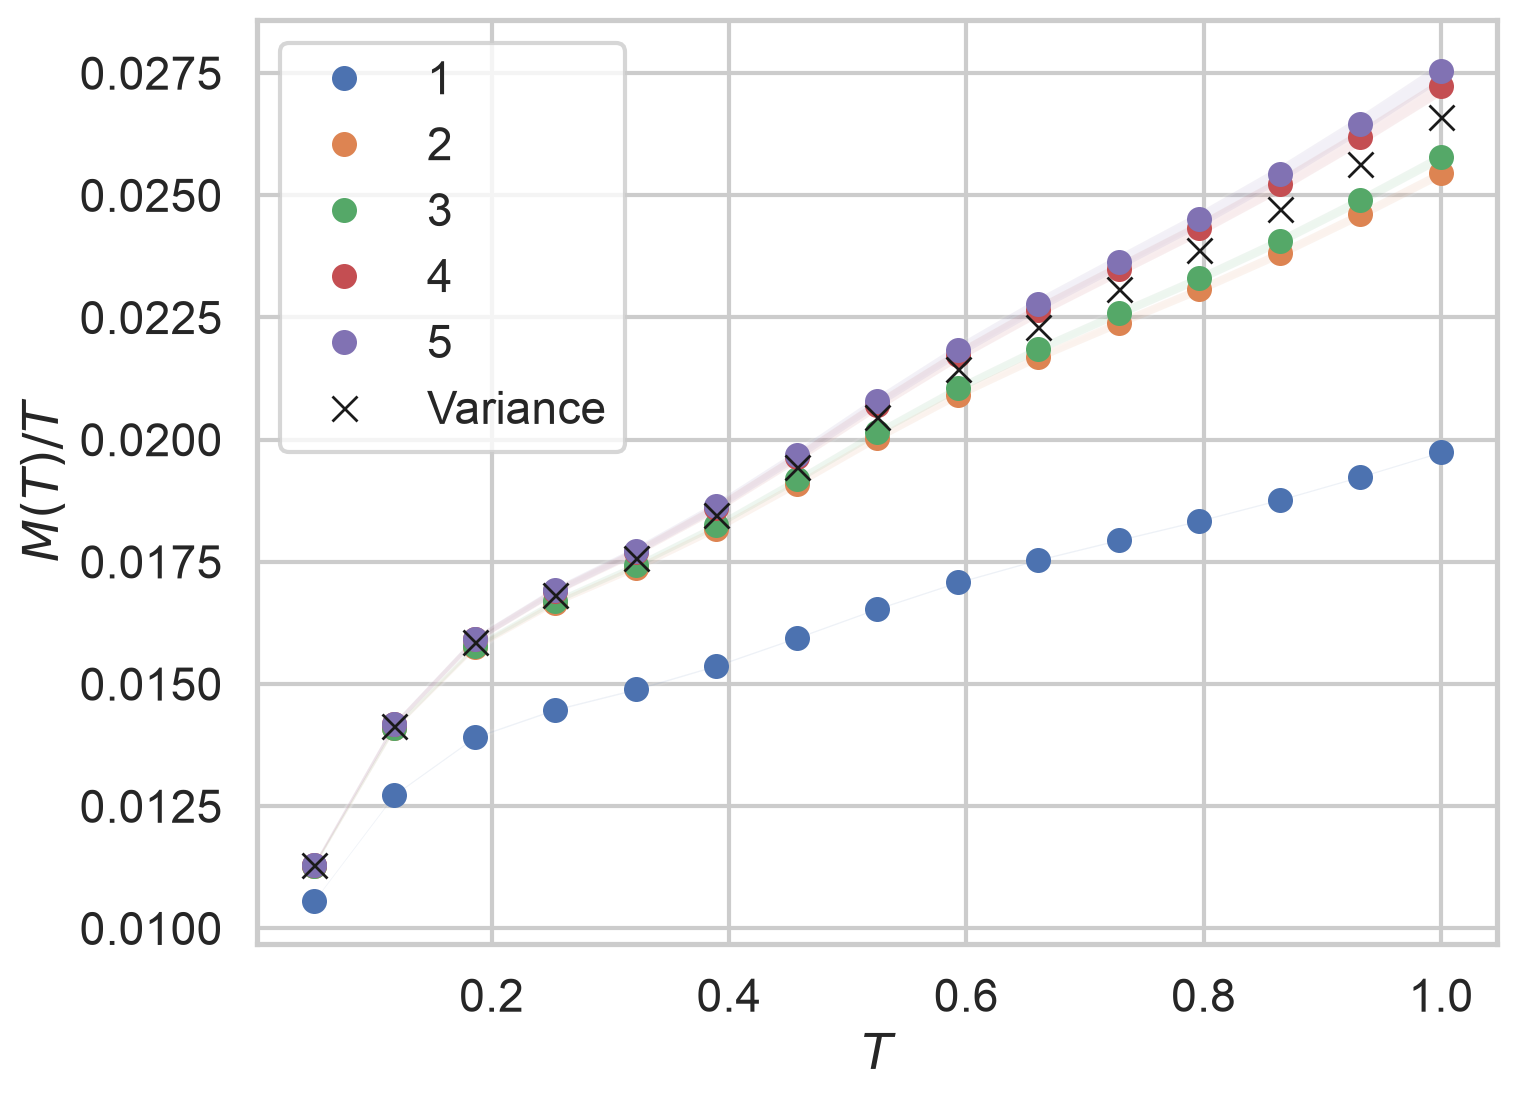

In [14]:
opt = "variance"
labels = {
    "variance": "Variance",
    "gamma": "Gamma",
}
ylabels = {
    "variance": r"$M(T)/T$",
    "gamma": r"$G(T) / T$",
}

fig, ax = plt.subplots()
# Magic Strikes
list_orders = [x for x in out_magic_strikes[opt] if isinstance(x, int)]
for order in list_orders:
    ax.plot(
        Ts,
        out_magic_strikes[opt][order] / Ts,
        ".",
        markersize=16,
        label=rf"{order}",
    )
    if n_batch > 1:
        ax.fill_between(
            Ts,
            out_magic_strikes[opt][f"{order}_low"] / Ts,
            out_magic_strikes[opt][f"{order}_high"] / Ts,
            alpha=0.1,
        )
# Monte Carlo (except for variance swap)
ax.plot(Ts, out_mc[opt] / Ts, "kx", label=labels[opt])
if n_batch > 1 and opt != "variance":
    ax.fill_between(
        Ts,
        out_mc[f"{opt}_low"] / Ts,
        out_mc[f"{opt}_high"] / Ts,
        color="k",
        alpha=0.1,
    )
ax.legend(ncol=1, loc="best")
ax.set_xlabel("$T$")
ax.set_ylabel(ylabels[opt])
# ax.set_ylim(0.01, 0.046)
if SAVEFIG:
    fig.savefig(
        f"figures/{opt}_swap_magic_strikes_rbergomi_set_{set_id}.pdf",
        bbox_inches="tight",
    )
plt.show()